Install Dependencies

In [ ]:
!pip install xgboost --quiet
!pip install scikit-learn==1.8.0
!pip install tldextract --quiet

Imports & Setup

In [ ]:
# Core utilities
import os
import re
import joblib
import numpy as np
import pandas as pd
import tldextract
import matplotlib.pyplot as plt

from urllib.parse import urlparse
from difflib import SequenceMatcher

# ML utilities
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

from xgboost import XGBClassifier

# Reproducibility
np.random.seed(42)

Load Dataset + Deduplication

In [ ]:
# Load dataset and remove null rows
df = pd.read_csv("dataset.csv").dropna()

# Prevent duplicate leakage across splits
df = df.drop_duplicates(subset=["url"])

print("Dataset Shape:", df.shape)

Dataset Shape: (186230, 2)


Train/Test Split

In [ ]:
# Separate features and labels
X = df["url"]
y = df["label"]

# Test set remains untouched for final evaluation
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Train/Validation Split

In [ ]:
# Validation set used ONLY for threshold optimisation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.2,
    stratify=y_temp,
    random_state=42
)

TFIDF Lexical Features

In [ ]:
# Character n-grams capture typosquatting behaviour
tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    sublinear_tf=True,
    min_df=2,
    max_features=60000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

Logistic Regression

In [ ]:
# Balanced logistic regression improves phishing recall
log_model = LogisticRegression(
    max_iter=1000,
    solver="saga",
    C=2,
    class_weight="balanced",
    n_jobs=-1
)

log_model.fit(X_train_tfidf, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",2
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

Threat Intelligence Lists

In [ ]:
# Common impersonated brands
BRANDS = [
    "google","paypal","amazon","apple",
    "facebook","instagram","netflix",
    "bank","dropbox","linkedin"
]

# Suspicious TLD usage
RISKY_TLDS = {"zip","ru","tk","gq","ml","top","work"}

# Phishing keyword injections
PHISH_KEYWORDS = [
    "login","verify","update",
    "account","bank","signin",
    "secure","support","invoice"
]

Structural Feature Engineering

In [ ]:
def brand_similarity(domain: str) -> float:
    """Maximum similarity against known brands."""
    score = 0.0
    for brand in BRANDS:
        score = max(score, SequenceMatcher(None, domain, brand).ratio())
    return score


def is_ip(host: str) -> int:
    """Detect raw IP hosting."""
    return int(bool(re.search(r"\d{1,3}(?:\.\d{1,3}){3}", host)))


def extract_features(url: str) -> dict:

    parsed = urlparse(url)
    ext = tldextract.extract(url)

    domain = ext.domain.lower()
    suffix = ext.suffix.lower()
    host = parsed.netloc.lower()
    url_lower = url.lower()

    # Excessive subdomain nesting indicator
    sub_count = max(len(host.split(".")) - 2, 0)

    return {
        "url_length": len(url),
        "num_dots": url.count("."),
        "num_hyphens": url.count("-"),
        "num_digits": sum(c.isdigit() for c in url),

        # Fake HTTPS keyword inside domain
        "has_https_token": int("https" in domain),

        "is_ip": is_ip(host),

        # Keyword injection score
        "keyword_score": sum(k in url_lower for k in PHISH_KEYWORDS),

        "brand_similarity": brand_similarity(domain),

        "risky_tld": int(suffix in RISKY_TLDS),

        "subdomain_count": sub_count
    }

Structural Extraction

In [ ]:
# Convert URLs into structured behavioural features
X_train_struct = pd.DataFrame(map(extract_features, X_train))
X_val_struct = pd.DataFrame(map(extract_features, X_val))
X_test_struct = pd.DataFrame(map(extract_features, X_test))

Random Forest + XGBoost

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_struct, y_train)


xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train_struct, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

Threshold Optimisation (Validation Only)

In [ ]:
def find_threshold(model, X, y):

    prob = model.predict_proba(X)[:, 1]

    fpr, tpr, thr = roc_curve(y, prob)

    # Maximise TPR − FPR
    return thr[np.argmax(tpr - fpr)]


log_th = find_threshold(log_model, X_val_tfidf, y_val)
rf_th = find_threshold(rf, X_val_struct, y_val)
xgb_th = find_threshold(xgb, X_val_struct, y_val)

print(log_th, rf_th, xgb_th)

0.2490648135146014 0.5233801913185597 0.37825608253479004


Stress URLs

In [ ]:
stress_urls = [

# ================= ORIGINAL TESTS =================

"http://secure-login-update-account-verify-bank-support.com/login",
"http://192.168.1.200/login",
"http://paypal-secure-verification.ru",
"http://google.com.secure-login.ru",
"https-secure-google-login.com",
"https://www.wikipedia.org",

# ================= HOMOGLYPH / TYPOSQUATTING =================

"http://paypaI-secure.com",                 # I instead of l
"http://g00gle-security-update.com",        # zeros instead of o
"http://micr0soft-login-support.net",

# ================= KEYWORD OBFUSCATION =================

"http://acc0unt-ver1fy-support.com",
"http://secure-upd4te-bank-login.net",

# ================= HTTPS TRUST ABUSE =================

"https://secure-paypal.com.verify-account.ru",
"https://amazon.verify-update-login.tk",

# ================= MIXED BRAND INJECTION =================

"http://amazon-google-security-update.net",
"http://paypal-facebook-security-check.top",

# ================= STRUCTURAL CAMOUFLAGE =================

"http://paypal-support.com",
"http://amazon-helpdesk.org",

# ================= URL SHORTENER STYLE =================

"https://bit.ly/paypal-login-secure",
"https://tinyurl.com/verify-bank-account",

# ================= LONG LEGITIMATE URL (FALSE POSITIVE TRAP) =================

"https://docs.microsoft.com/en-us/security/advanced-threat-protection",
"https://developer.mozilla.org/en-US/docs/Web/Security",

# ================= BENIGN CONTROLS =================

"https://www.wikipedia.org",
"https://www.github.com",
"https://stackoverflow.com/questions"
]

In [ ]:
# ================= CLEAN STRESS TEST =================

def stress_test(urls):

    print("\n===== ADVERSARIAL STRESS TEST RESULTS =====")

    rows = []

    for url in urls:

        tfidf_vec = tfidf.transform([url])
        struct = pd.DataFrame([extract_features(url)])

        log_prob = log_model.predict_proba(tfidf_vec)[0][1]
        rf_prob = rf.predict_proba(struct)[0][1]
        xgb_prob = xgb.predict_proba(struct)[0][1]

        final_score = np.mean(
            [log_prob, rf_prob, xgb_prob]
        )

        rows.append({
            "URL": url,
            "Logistic": round(log_prob,4),
            "RF": round(rf_prob,4),
            "XGB": round(xgb_prob,4),
            "Final Score": round(final_score,4)
        })

    df = pd.DataFrame(rows)

    print(df.to_string(index=False))


stress_test(stress_urls)


===== ADVERSARIAL STRESS TEST RESULTS =====
                                                                 URL  Logistic     RF    XGB  Final Score
    http://secure-login-update-account-verify-bank-support.com/login    0.9997 0.4267 0.2282       0.5515
                                          http://192.168.1.200/login    0.9996 0.9967 0.9999       0.9987
                                http://paypal-secure-verification.ru    0.9899 0.4287 0.5286       0.6491
                                   http://google.com.secure-login.ru    0.9926 0.9798 0.9943       0.9889
                                       https-secure-google-login.com    0.8765 0.2193 0.0516       0.3825
                                           https://www.wikipedia.org    0.1844 0.1600 0.0697       0.1380
                                            http://paypaI-secure.com    0.9668 0.0663 0.0428       0.3586
                                   http://g00gle-security-update.com    0.9811 0.2400 0.2021       0.4744
 

Evaluation + Confusion Matrix

In [ ]:
def evaluate(name, model, X, threshold):

    prob = model.predict_proba(X)[:, 1]
    pred = (prob >= threshold).astype(int)

    print("\n", name)
    print(classification_report(y_test, pred))

    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign","Phishing"]
    )

    disp.plot(cmap="Blues", colorbar=False)

    plt.title(f"{name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

Generate Graphical Matrices


 TFIDF Logistic
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22352
           1       1.00      0.99      0.99     14894

    accuracy                           1.00     37246
   macro avg       1.00      1.00      1.00     37246
weighted avg       1.00      1.00      1.00     37246



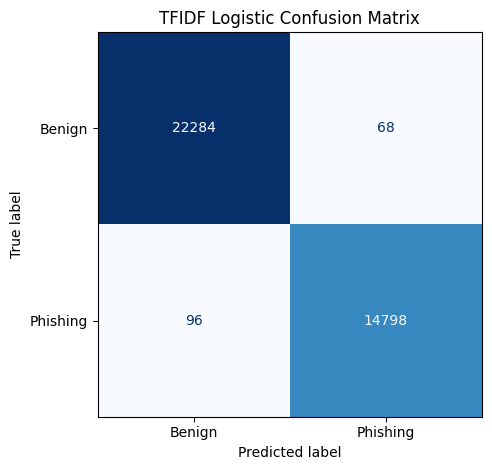


 Structural RF
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     22352
           1       0.98      0.96      0.97     14894

    accuracy                           0.97     37246
   macro avg       0.98      0.97      0.97     37246
weighted avg       0.97      0.97      0.97     37246



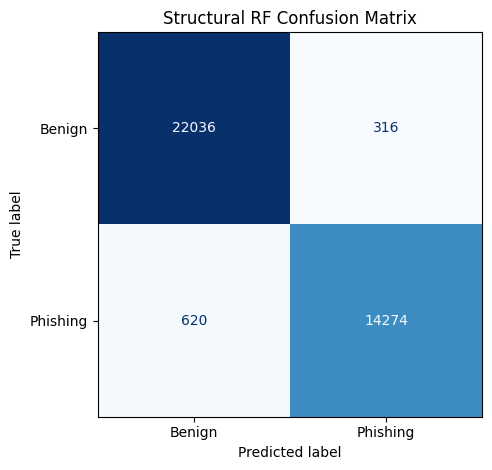


 Structural XGB
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     22352
           1       0.98      0.96      0.97     14894

    accuracy                           0.97     37246
   macro avg       0.97      0.97      0.97     37246
weighted avg       0.97      0.97      0.97     37246



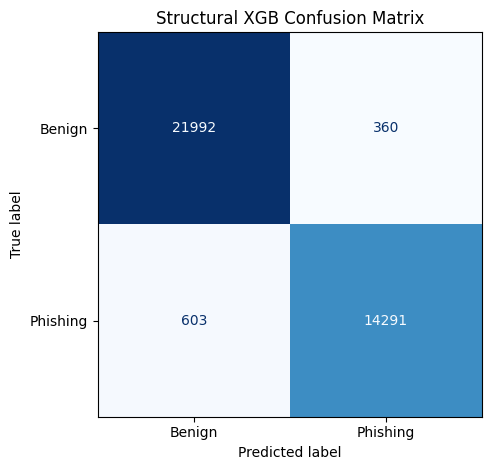

In [ ]:
# Logistic Lexical Model
evaluate(
    "TFIDF Logistic",
    log_model,
    X_test_tfidf,
    log_th
)

# Random Forest Structural Model
evaluate(
    "Structural RF",
    rf,
    X_test_struct,
    rf_th
)

# XGBoost Structural Model
evaluate(
    "Structural XGB",
    xgb,
    X_test_struct,
    xgb_th
)

Error Analysis

In [ ]:
prob = log_model.predict_proba(X_test_tfidf)[:, 1]

pred = (prob >= log_th).astype(int)

errors = pd.DataFrame({
    "url": X_test.values,
    "true": y_test.values,
    "pred": pred
})

false_neg = errors[(errors.true == 1) & (errors.pred == 0)]
false_pos = errors[(errors.true == 0) & (errors.pred == 1)]

print("False Negatives:", len(false_neg))
print("False Positives:", len(false_pos))

False Negatives: 96
False Positives: 68


Save Deployment Objects

In [ ]:
os.makedirs("models", exist_ok=True)

joblib.dump(tfidf, "models/tfidf.pkl")
joblib.dump(log_model, "models/logistic.pkl")
joblib.dump(rf, "models/rf.pkl")
joblib.dump(xgb, "models/xgb.pkl")

joblib.dump(
    {
        "log_th": log_th,
        "rf_th": rf_th,
        "xgb_th": xgb_th
    },
    "models/thresholds.pkl"
)

print("Deployment Objects Saved")

Deployment Objects Saved
